<a href="https://colab.research.google.com/github/Gutavo2000/LCE0212---Estat-stica-Aplicada-s-Ci-ncias-dos-Alimentos/blob/main/tarefa13_Python_Ciencias_dos_Alimentos_Grupo7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Gustavo Gabriel da Silva Rodrigues Nº USP: 11373741  

##Henrique de Angelo Silva Nº USP: 178960221

##Luciana Gouveia dos Santos Nº USP: 15472401

# Tarefa 13

## Objetivo
Investigar como as distribuições Normal, t de Student, qui-quadrado e F de Fisher aparecem em perguntas estatísticas sobre propriedades físico-químicas de vinhos. As distribuições são usadas para modelar quantidades diferentes: uma medição, uma estatística padronizada, uma estatística de variância ou uma razão de variâncias.

> **Importante:** desenhar uma curva não demonstra que os dados seguem aquela distribuição. As interpretações abaixo explicitam as hipóteses e limitações.

## 1. Base de dados, origem e critérios

**Base:** *Wine Quality* (vinhos tintos e brancos, região do norte de Portugal).  
**Instituição responsável:** UCI Machine Learning Repository.  
**Link:** https://archive.ics.uci.edu/dataset/186/wine+quality  
**Arquivo de distribuição:** https://archive.ics.uci.edu/static/public/186/wine+quality.zip  
**Data de acesso/consulta:** 04/10/2026.

Cada linha representa uma amostra de vinho analisada; as colunas são medidas físico-químicas (por exemplo, álcool, pH, acidez e dióxido de enxofre) e uma avaliação sensorial de qualidade. Os registros não são médias de grupos, e sim observações individuais do conjunto publicado. A variável `alcohol` é expressa em **% por volume** segundo a descrição do conjunto. O arquivo não identifica necessariamente lotes independentes, produtores ou condições de coleta; portanto, independência e representatividade populacional não podem ser garantidas.

**Critérios de seleção:** usar as observações de álcool dos arquivos de vinho tinto e branco; excluir apenas valores ausentes ou não numéricos em `alcohol`. Para comparar variâncias, manter os dois grupos separados. A classificação de cor vem do arquivo de origem, não de inferência feita a partir das medições.

Os arquivos são obtidos diretamente do pacote público da UCI durante a execução. Se a conexão falhar, baixe o ZIP pelo link acima e coloque `winequality-red.csv` e `winequality-white.csv` na mesma pasta do notebook. Verifique a licença e os termos da UCI antes de redistribuir os arquivos.

In [ ]:
import io
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

URL = "https://archive.ics.uci.edu/static/public/186/wine+quality.zip"

try:
    with urllib.request.urlopen(URL, timeout=30) as response:
        zip_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        red_name = next(n for n in zf.namelist() if n.endswith("winequality-red.csv"))
        white_name = next(n for n in zf.namelist() if n.endswith("winequality-white.csv"))
        red = pd.read_csv(zf.open(red_name), sep=";")
        white = pd.read_csv(zf.open(white_name), sep=";")
except Exception as exc:
    print("Não foi possível baixar automaticamente:", exc)
    print("Coloque os CSVs baixados da UCI na pasta do notebook e execute novamente.")
    red = pd.read_csv("winequality-red.csv", sep=";")
    white = pd.read_csv("winequality-white.csv", sep=";")

red["alcohol"] = pd.to_numeric(red["alcohol"], errors="coerce")
white["alcohol"] = pd.to_numeric(white["alcohol"], errors="coerce")
red_alc = red["alcohol"].dropna().to_numpy()
white_alc = white["alcohol"].dropna().to_numpy()

print(f"Vinho tinto: n={len(red_alc)}, álcool médio={red_alc.mean():.3f}%, desvio-padrão={red_alc.std(ddof=1):.3f}")
print(f"Vinho branco: n={len(white_alc)}, álcool médio={white_alc.mean():.3f}%, desvio-padrão={white_alc.std(ddof=1):.3f}")
print("Valores ausentes em álcool — tinto:", red["alcohol"].isna().sum(), "| branco:", white["alcohol"].isna().sum())
display(pd.DataFrame({
    "grupo": ["Tinto", "Branco"],
    "n": [len(red_alc), len(white_alc)],
    "média álcool (% vol.)": [red_alc.mean(), white_alc.mean()],
    "desvio-padrão": [red_alc.std(ddof=1), white_alc.std(ddof=1)],
    "mínimo": [red_alc.min(), white_alc.min()],
    "mediana": [np.median(red_alc), np.median(white_alc)],
    "máximo": [red_alc.max(), white_alc.max()]
}))

Vinho tinto: n=1599, álcool médio=10.423%, desvio-padrão=1.066
Vinho branco: n=4898, álcool médio=10.514%, desvio-padrão=1.231
Valores ausentes em álcool — tinto: 0 | branco: 0


,grupo,n,média álcool (% vol.),desvio-padrão,mínimo,mediana,máximo
0,Tinto,1599,10.422983,1.065668,8.4,10.2,14.9
1,Branco,4898,10.514267,1.230621,8.0,10.4,14.2


## 2. Distribuição Normal

### Densidade e parâmetros
A função densidade é
$$
f(x\mid\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right],
\qquad -\infty<x<\infty.
$$
- \($x$\): valor da variável contínua; \($\mu\in\mathbb{R}$\): média, que desloca a curva horizontalmente.
- ($sigma>0$): desvio-padrão; valores maiores deixam a curva mais espalhada e mais baixa.
- A curva é simétrica em torno de \(\$mu$\); a área total sob ela é 1.

**Contexto:** usaremos a Normal como aproximação descritiva para a concentração de álcool dos vinhos tintos, com parâmetros estimados pela média e pelo desvio-padrão amostrais. O modelo refere-se à distribuição de uma medição individual idealizada, não à distribuição das médias. A adequação deve ser verificada; os dados podem ser assimétricos, arredondados ou conter subgrupos.

**Fonte da fórmula e parâmetros:** SciPy, `scipy.stats.norm` — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html  
**Referência de apoio:** NIST/SEMATECH e-Handbook of Statistical Methods — https://www.itl.nist.gov/div898/handbook/

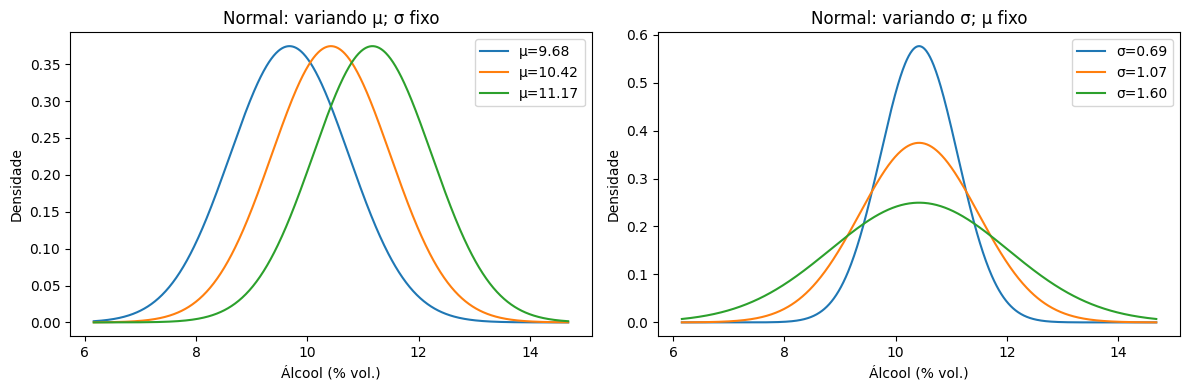

In [ ]:
mu_n = red_alc.mean()
sigma_n = red_alc.std(ddof=1)
x = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 800)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mu in [mu_n - 0.7*sigma_n, mu_n, mu_n + 0.7*sigma_n]:
    axes[0].plot(x, stats.norm.pdf(x, loc=mu, scale=sigma_n), label=f"μ={mu:.2f}")
axes[0].set_title("Normal: variando μ; σ fixo")
axes[0].set_xlabel("Álcool (% vol.)"); axes[0].set_ylabel("Densidade"); axes[0].legend()

for sigma in [0.65*sigma_n, sigma_n, 1.5*sigma_n]:
    axes[1].plot(x, stats.norm.pdf(x, loc=mu_n, scale=sigma), label=f"σ={sigma:.2f}")
axes[1].set_title("Normal: variando σ; μ fixo")
axes[1].set_xlabel("Álcool (% vol.)"); axes[1].set_ylabel("Densidade"); axes[1].legend()
plt.tight_layout()
plt.show()

### Pergunta contextualizada e probabilidades — Normal
**Pergunta:** se o álcool de um vinho tinto fosse descrito aproximadamente por uma Normal com média e desvio-padrão estimados na amostra, qual seria a probabilidade modelada de (a) ter até 10% vol.; (b) ficar entre 9% e 12% vol.; e (c) ultrapassar 12% vol.? O percentil 90 indica um limite acima do qual ficam, no modelo, 10% dos valores.

A função `cdf` calcula \($P(X\le x)$\), `sf` calcula \($P(X>x)\$), `ppf` calcula o quantil correspondente a uma probabilidade acumulada e `pdf` calcula densidade — não probabilidade pontual.

P(X ≤ 10.0) = 0.3457
P(9 ≤ X ≤ 12) = 0.8397
P(X > 12.0) = 0.0695
Percentil 90 = 11.789% vol. (90% abaixo, 10% acima no modelo)


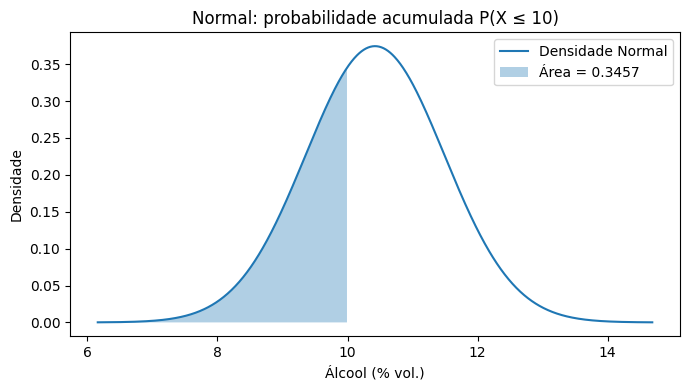

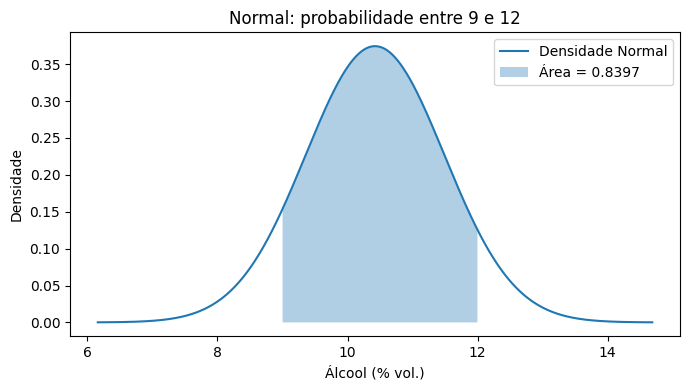

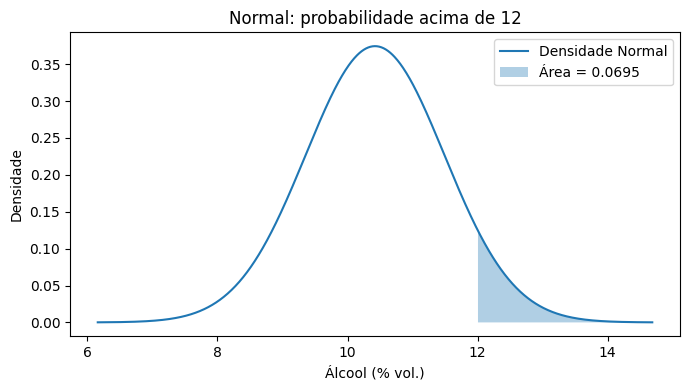

In [ ]:
a, b, c = 10.0, 9.0, 12.0
p_le_a = stats.norm.cdf(a, loc=mu_n, scale=sigma_n)
p_between = stats.norm.cdf(12.0, loc=mu_n, scale=sigma_n) - stats.norm.cdf(9.0, loc=mu_n, scale=sigma_n)
p_gt_c = stats.norm.sf(c, loc=mu_n, scale=sigma_n)
q90 = stats.norm.ppf(0.90, loc=mu_n, scale=sigma_n)
print(f"P(X ≤ {a:.1f}) = {p_le_a:.4f}")
print(f"P(9 ≤ X ≤ 12) = {p_between:.4f}")
print(f"P(X > {c:.1f}) = {p_gt_c:.4f}")
print(f"Percentil 90 = {q90:.3f}% vol. (90% abaixo, 10% acima no modelo)")

def shaded_normal(title, lo=None, hi=None, prob=None):
    grid = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 1000)
    dens = stats.norm.pdf(grid, mu_n, sigma_n)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grid, dens, label="Densidade Normal")
    mask = np.ones_like(grid, dtype=bool)
    if lo is not None: mask &= grid >= lo
    if hi is not None: mask &= grid <= hi
    ax.fill_between(grid, 0, dens, where=mask, alpha=0.35, label=f"Área = {prob:.4f}")
    ax.set_title(title); ax.set_xlabel("Álcool (% vol.)"); ax.set_ylabel("Densidade")
    ax.legend(); plt.tight_layout(); plt.show()

shaded_normal("Normal: probabilidade acumulada P(X ≤ 10)", hi=10, prob=p_le_a)
shaded_normal("Normal: probabilidade entre 9 e 12", lo=9, hi=12, prob=p_between)
shaded_normal("Normal: probabilidade acima de 12", lo=12, prob=p_gt_c)

**Interpretação e limitações:** essas probabilidades são implicações do modelo Normal ajustado, não frequências garantidas da população. Compare-as com o histograma e um gráfico Q–Q; se houver assimetria ou multimodalidade, a aproximação pode ser ruim.

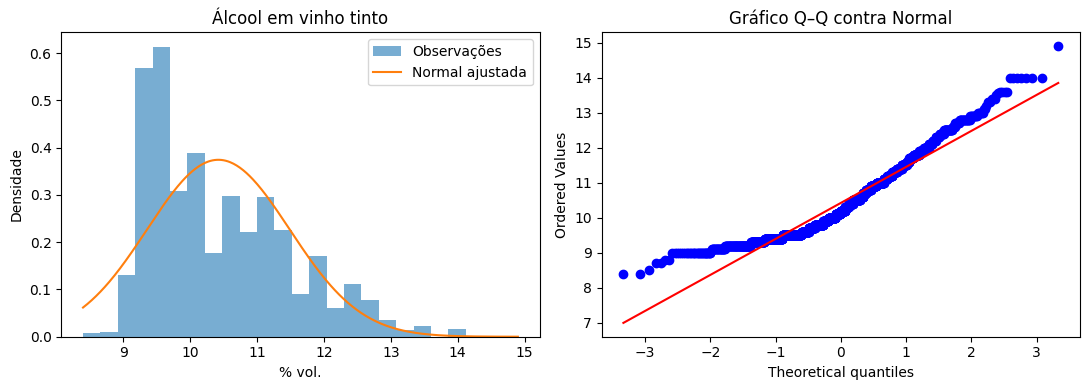

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(red_alc, bins=25, density=True, alpha=0.6, label="Observações")
grid = np.linspace(red_alc.min(), red_alc.max(), 400)
axes[0].plot(grid, stats.norm.pdf(grid, mu_n, sigma_n), label="Normal ajustada")
axes[0].set_title("Álcool em vinho tinto"); axes[0].set_xlabel("% vol."); axes[0].set_ylabel("Densidade"); axes[0].legend()
stats.probplot(red_alc, dist="norm", plot=axes[1])
axes[1].set_title("Gráfico Q–Q contra Normal")
plt.tight_layout(); plt.show()

## 3. Distribuição t de Student

### Densidade e parâmetros
$$
f(t\mid\nu)=\frac{\Gamma\left(\frac{\nu+1}{2}\right)}
{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)}
\left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}},
\qquad -\infty<t<\infty,\quad \nu>0.
$$

- $t$ é uma estatística padronizada; $\nu$ são os graus de liberdade, positivos (na aplicação clássica de uma amostra, inteiros $n-1$).
- A distribuição é simétrica, centrada em zero. Graus de liberdade menores produzem caudas mais pesadas; quando $\nu$ aumenta, a curva se aproxima da Normal padrão.
- $\Gamma$ é a função gama.

**Contexto:** para uma amostra independente de uma população Normal com variância desconhecida, a estatística \($T=(\bar X-\mu_0)/(S/\sqrt n)$\) segue uma t com \($n-1$\) graus de liberdade sob a hipótese de que a média populacional seja \($\mu_0$\). Ela não é uma medição individual de álcool: é uma estatística calculada a partir da amostra.

**Fonte:** SciPy, `scipy.stats.t` — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

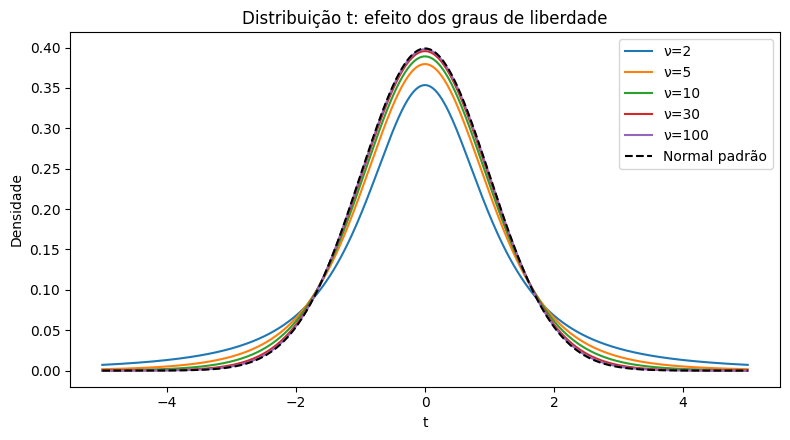

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
grid = np.linspace(-5, 5, 1000)
for df in [2, 5, 10, 30, 100]:
    ax.plot(grid, stats.t.pdf(grid, df), label=f"ν={df}")
ax.plot(grid, stats.norm.pdf(grid), "k--", label="Normal padrão")
ax.set_title("Distribuição t: efeito dos graus de liberdade")
ax.set_xlabel("t"); ax.set_ylabel("Densidade"); ax.legend()
plt.tight_layout(); plt.show()

### Pergunta contextualizada e probabilidades — t
**Pergunta:** supondo que os vinhos tintos possam ser tratados como uma amostra aleatória independente de uma população aproximadamente Normal, qual é a probabilidade teórica de a estatística t para testar \($H_0:\mu=10\%$\) vol. ser (a) menor ou igual a 0; (b) ficar entre −2 e 2; e (c) ser maior que 2? Aqui os limites são valores da estatística t, não porcentagens de álcool. A hipótese de média 10% é um valor de referência didático; não é uma conclusão sobre qualidade do vinho.

Graus de liberdade = 1598
P(T ≤ 0) = 0.5000
P(-2 ≤ T ≤ 2) = 0.9543
P(T > 2) = 0.0228
Percentil 95 de T = 1.6458


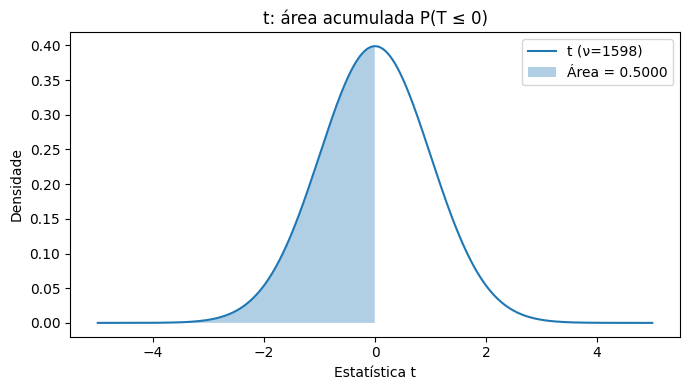

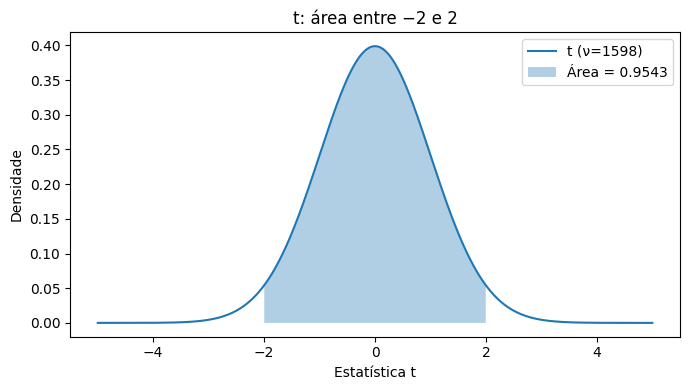

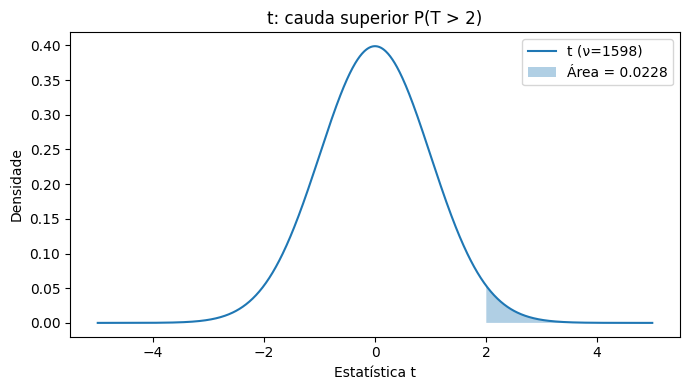

In [ ]:
n_t = len(red_alc)
df_t = n_t - 1
t_lo, t_hi = -2.0, 2.0
p_t_le0 = stats.t.cdf(0, df_t)
p_t_between = stats.t.cdf(t_hi, df_t) - stats.t.cdf(t_lo, df_t)
p_t_gt2 = stats.t.sf(2, df_t)
t_q95 = stats.t.ppf(0.95, df_t)
print(f"Graus de liberdade = {df_t}")
print(f"P(T ≤ 0) = {p_t_le0:.4f}")
print(f"P(-2 ≤ T ≤ 2) = {p_t_between:.4f}")
print(f"P(T > 2) = {p_t_gt2:.4f}")
print(f"Percentil 95 de T = {t_q95:.4f}")

def shaded_t(title, lo=None, hi=None, prob=None):
    grid = np.linspace(-5, 5, 1000); dens = stats.t.pdf(grid, df_t)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grid, dens, label=f"t (ν={df_t})")
    mask = np.ones_like(grid, dtype=bool)
    if lo is not None: mask &= grid >= lo
    if hi is not None: mask &= grid <= hi
    ax.fill_between(grid, 0, dens, where=mask, alpha=0.35, label=f"Área = {prob:.4f}")
    ax.set_title(title); ax.set_xlabel("Estatística t"); ax.set_ylabel("Densidade")
    ax.legend(); plt.tight_layout(); plt.show()

shaded_t("t: área acumulada P(T ≤ 0)", hi=0, prob=p_t_le0)
shaded_t("t: área entre −2 e 2", lo=-2, hi=2, prob=p_t_between)
shaded_t("t: cauda superior P(T > 2)", lo=2, prob=p_t_gt2)

**Interpretação e limitações:** o percentil 95 é o valor crítico abaixo do qual ficam 95% dos valores de uma distribuição t com esses graus de liberdade. Como o conjunto publicado pode não ser uma amostra aleatória simples e a variável pode não ser Normal, a interpretação inferencial exige cautela. Para inferência sobre uma média, a t é especialmente justificável sob independência e Normalidade aproximada, ou com amostras grandes e condições adequadas.

## 4. Distribuição qui-quadrado (χ²)

### Densidade e parâmetros
$$
f(x\mid k)=\frac{1}{2^{k/2}\Gamma(k/2)}
x^{k/2-1}e^{-x/2},
\qquad x>0,\quad k>0.
$$

- $x$ só pode ser positivo; $k$ é o número de graus de liberdade (positivo; em aplicações clássicas de variância, inteiro $n-1$).
- A curva é assimétrica à direita. Com mais graus de liberdade, a massa se desloca para valores maiores e a forma fica relativamente menos assimétrica.
- $\Gamma$ é a função gama.

**Contexto:** se uma amostra de tamanho \(n\) vier de uma população Normal com variância \(\$sigma^2$\), então \$((n-1)S^2/\sigma^2\$) segue χ² com \(n-1\) graus de liberdade. Trata-se de uma estatística calculada da variância amostral, não de uma concentração individual.

**Fonte:** SciPy, `scipy.stats.chi2` — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

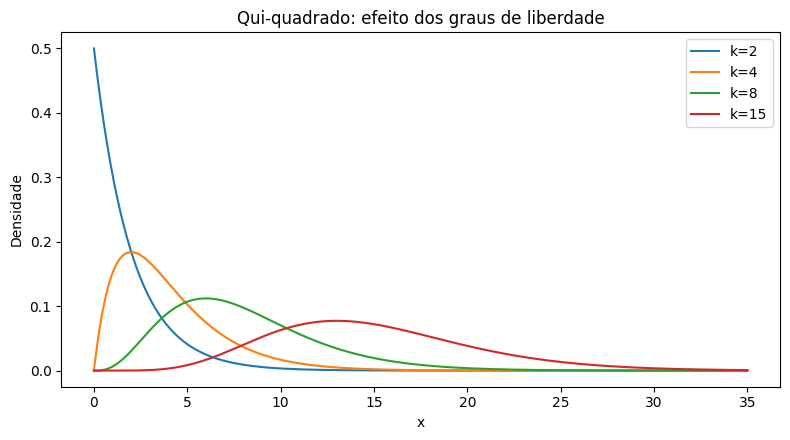

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
grid = np.linspace(0.001, 35, 1000)
for k in [2, 4, 8, 15]:
    ax.plot(grid, stats.chi2.pdf(grid, k), label=f"k={k}")
ax.set_title("Qui-quadrado: efeito dos graus de liberdade")
ax.set_xlabel("x"); ax.set_ylabel("Densidade"); ax.legend()
plt.tight_layout(); plt.show()

### Pergunta contextualizada e probabilidades — qui-quadrado
**Pergunta:** sob a hipótese de que o álcool dos vinhos tintos venha de uma população Normal cuja variância verdadeira seja igual ao quadrado do desvio-padrão observado nesta amostra, qual a probabilidade teórica de uma estatística qui-quadrado ser (a) até $n-1$; (b) entre os percentis 25 e 75; e (c) acima do percentil 95?

Para que a pergunta não dependa de limites arbitrários, usamos quantis teóricos como limites. A estatística é $(n-1)S^2/\sigma_0^2$, com $\sigma_0$ definido como referência abaixo; não é uma medição individual.

Graus de liberdade = 1598; estatística observada com σ₀² = S²: 1598.000
P(χ² ≤ n−1) = 0.5047
P(q25 ≤ χ² ≤ q75) = 0.5000
P(χ² > q95) = 0.0500
Percentil 90 de χ² = 1670.865


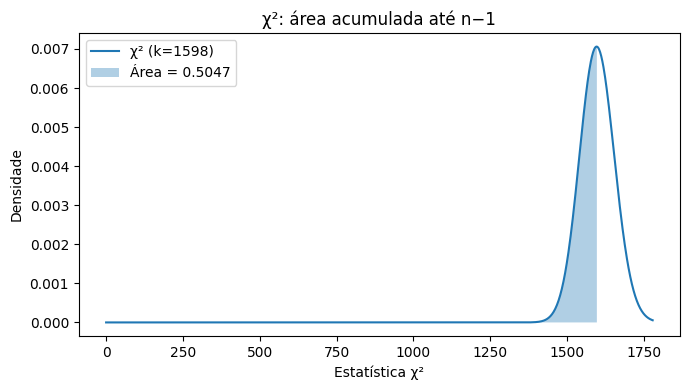

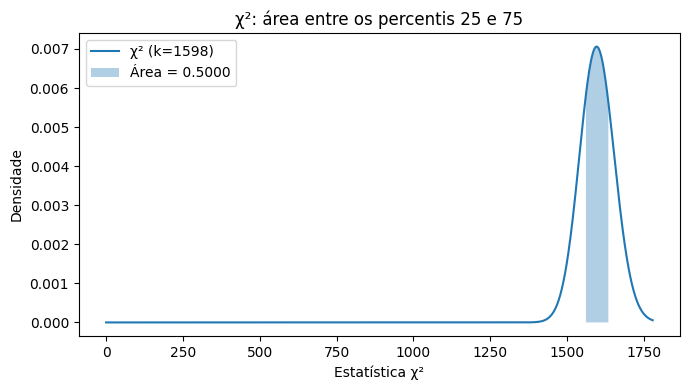

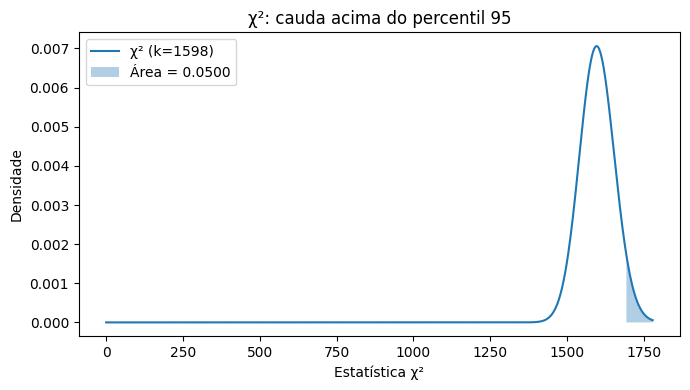

In [ ]:
n_chi = len(red_alc)
df_chi = n_chi - 1
# Valor de referência explícito: variância amostral observada; serve para ilustrar a estatística.
sigma0_sq = red_alc.var(ddof=1)
chi_stat_obs = df_chi * red_alc.var(ddof=1) / sigma0_sq
q25_chi, q75_chi, q95_chi = stats.chi2.ppf([0.25, 0.75, 0.95], df_chi)
p_chi_le = stats.chi2.cdf(df_chi, df_chi)
p_chi_between = stats.chi2.cdf(q75_chi, df_chi) - stats.chi2.cdf(q25_chi, df_chi)
p_chi_gt = stats.chi2.sf(q95_chi, df_chi)
print(f"Graus de liberdade = {df_chi}; estatística observada com σ₀² = S²: {chi_stat_obs:.3f}")
print(f"P(χ² ≤ n−1) = {p_chi_le:.4f}")
print(f"P(q25 ≤ χ² ≤ q75) = {p_chi_between:.4f}")
print(f"P(χ² > q95) = {p_chi_gt:.4f}")
print(f"Percentil 90 de χ² = {stats.chi2.ppf(0.90, df_chi):.3f}")

def shaded_chi(title, lo=None, hi=None, prob=None):
    grid = np.linspace(0.001, stats.chi2.ppf(0.999, df_chi), 1000)
    dens = stats.chi2.pdf(grid, df_chi)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grid, dens, label=f"χ² (k={df_chi})")
    mask = np.ones_like(grid, dtype=bool)
    if lo is not None: mask &= grid >= lo
    if hi is not None: mask &= grid <= hi
    ax.fill_between(grid, 0, dens, where=mask, alpha=0.35, label=f"Área = {prob:.4f}")
    ax.set_title(title); ax.set_xlabel("Estatística χ²"); ax.set_ylabel("Densidade")
    ax.legend(); plt.tight_layout(); plt.show()

shaded_chi("χ²: área acumulada até n−1", hi=df_chi, prob=p_chi_le)
shaded_chi("χ²: área entre os percentis 25 e 75", lo=q25_chi, hi=q75_chi, prob=p_chi_between)
shaded_chi("χ²: cauda acima do percentil 95", lo=q95_chi, prob=p_chi_gt)

**Interpretação e limitações:** a área entre os percentis 25 e 75 deve ser aproximadamente 0,50 por definição dos quantis; a área acima do percentil 95 deve ser 0,05. O uso inferencial de χ² para variância depende fortemente da Normalidade da população. Como o álcool pode não ser Normal e a amostra pode ter dependência, este cálculo é uma demonstração condicionada às hipóteses, não uma prova sobre o processo de produção.

## 5. Distribuição F de Fisher-Snedecor

### Densidade e parâmetros
$$
f(x\mid d_1,d_2)=
\frac{\left(\frac{d_1}{d_2}\right)^{d_1/2}
x^{d_1/2-1}}
{B(d_1/2,d_2/2)
\left(1+\frac{d_1}{d_2}x\right)^{(d_1+d_2)/2}},
\qquad x>0.
$$

- $d_1>0$: graus de liberdade do numerador; $d_2>0$: graus de liberdade do denominador. Em comparações clássicas de variâncias, são inteiros $n_1-1$ e $n_2-1$.
- $B(a,b)$ é a função beta. A curva é positiva e assimétrica à direita.
- Alterar $d_1$ muda a distribuição do numerador; alterar $d_2$ muda a do denominador. Os dois efeitos devem ser analisados separadamente.

**Contexto:** para duas amostras independentes de populações Normais, a razão $F=S_1^2/S_2^2$ segue uma distribuição F escalada pela razão das variâncias populacionais; sob variâncias iguais, a razão das variâncias amostrais segue F com $d_1=n_1-1$ e $d_2=n_2-1$.

Essa análise compara a dispersão de álcool em vinhos tintos e brancos. Não basta haver dois grupos: independência e Normalidade são pressupostos importantes, e a razão de variâncias é sensível a desvios de Normalidade.

**Fonte:** SciPy, `scipy.stats.f` — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

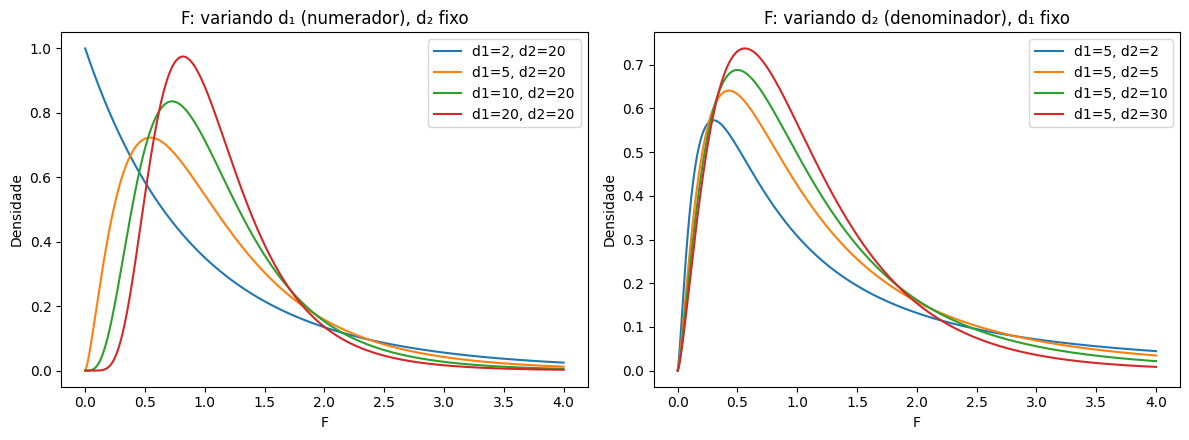

In [ ]:
grid = np.linspace(0.001, 4, 1000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
d2_fixed = 20
for d1 in [2, 5, 10, 20]:
    axes[0].plot(grid, stats.f.pdf(grid, d1, d2_fixed), label=f"d1={d1}, d2={d2_fixed}")
axes[0].set_title("F: variando d₁ (numerador), d₂ fixo")
axes[0].set_xlabel("F"); axes[0].set_ylabel("Densidade"); axes[0].legend()
d1_fixed = 5
for d2 in [2, 5, 10, 30]:
    axes[1].plot(grid, stats.f.pdf(grid, d1_fixed, d2), label=f"d1={d1_fixed}, d2={d2}")
axes[1].set_title("F: variando d₂ (denominador), d₁ fixo")
axes[1].set_xlabel("F"); axes[1].set_ylabel("Densidade"); axes[1].legend()
plt.tight_layout(); plt.show()

### Pergunta contextualizada e probabilidades — F
**Pergunta:** sob a hipótese de que as variâncias populacionais de álcool em vinho tinto e branco sejam iguais e de que os grupos sejam independentes e Normalmente distribuídos, qual a probabilidade teórica de a razão de variâncias F ser (a) até 1; (b) ficar entre 0,5 e 2; e (c) ultrapassar 2? O valor 1 representa variâncias amostrais iguais; uma razão acima de 2 representa, nesta escala, uma variância do numerador duas vezes a do denominador. Para a estatística observada, colocaremos o grupo tinto no numerador e o branco no denominador.

n tinto=1599, n branco=4898; d1=1598, d2=4897
Variância amostral tinto=1.1356; branco=1.5144; F observado=0.7499
P(F ≤ 1) = 0.5028
P(0.5 ≤ F ≤ 2) = 1.0000
P(F > 2) = 0.0000
Percentil 95 de F = 1.0686


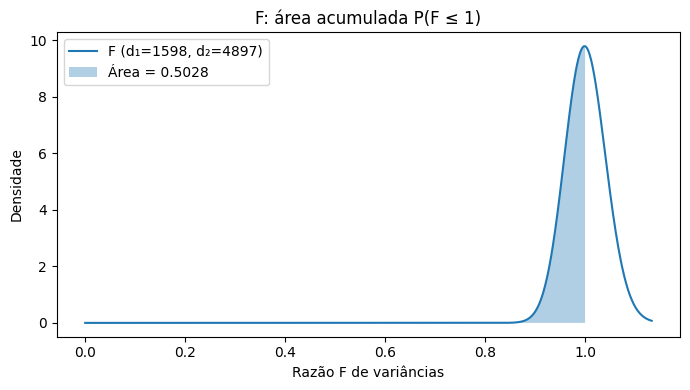

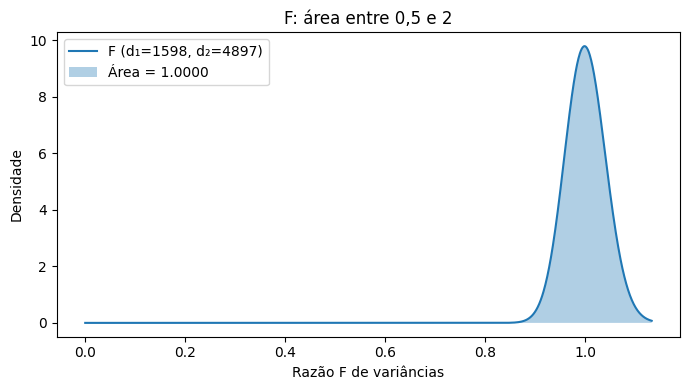

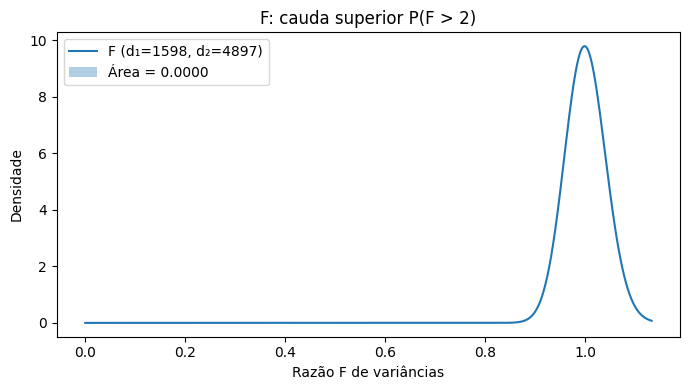

In [ ]:
n1, n2 = len(red_alc), len(white_alc)
d1, d2 = n1 - 1, n2 - 1
s1_sq, s2_sq = red_alc.var(ddof=1), white_alc.var(ddof=1)
f_obs = s1_sq / s2_sq
p_f_le1 = stats.f.cdf(1, d1, d2)
p_f_between = stats.f.cdf(2, d1, d2) - stats.f.cdf(0.5, d1, d2)
p_f_gt2 = stats.f.sf(2, d1, d2)
f_q95 = stats.f.ppf(0.95, d1, d2)
print(f"n tinto={n1}, n branco={n2}; d1={d1}, d2={d2}")
print(f"Variância amostral tinto={s1_sq:.4f}; branco={s2_sq:.4f}; F observado={f_obs:.4f}")
print(f"P(F ≤ 1) = {p_f_le1:.4f}")
print(f"P(0.5 ≤ F ≤ 2) = {p_f_between:.4f}")
print(f"P(F > 2) = {p_f_gt2:.4f}")
print(f"Percentil 95 de F = {f_q95:.4f}")

def shaded_f(title, lo=None, hi=None, prob=None):
    grid = np.linspace(0.001, stats.f.ppf(0.999, d1, d2), 1200)
    dens = stats.f.pdf(grid, d1, d2)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grid, dens, label=f"F (d₁={d1}, d₂={d2})")
    mask = np.ones_like(grid, dtype=bool)
    if lo is not None: mask &= grid >= lo
    if hi is not None: mask &= grid <= hi
    ax.fill_between(grid, 0, dens, where=mask, alpha=0.35, label=f"Área = {prob:.4f}")
    ax.set_title(title); ax.set_xlabel("Razão F de variâncias"); ax.set_ylabel("Densidade")
    ax.legend(); plt.tight_layout(); plt.show()

shaded_f("F: área acumulada P(F ≤ 1)", hi=1, prob=p_f_le1)
shaded_f("F: área entre 0,5 e 2", lo=0.5, hi=2, prob=p_f_between)
shaded_f("F: cauda superior P(F > 2)", lo=2, prob=p_f_gt2)

**Interpretação e limitações:** o percentil 95 é o ponto que deixa 95% da distribuição F à esquerda e 5% à direita, dados os graus de liberdade. A probabilidade teórica de \($F>2$\) não é a probabilidade de as variâncias serem diferentes; é uma probabilidade sob a distribuição de referência. A base pode conter amostras agrupadas por região ou produtor, e o álcool pode não seguir Normalidade. Para uma análise robusta de dispersão, considerar Levene ou Brown–Forsythe e apresentar gráficos por grupo, além da razão F clássica.

## 6. Síntese e conclusão

- **Normal:** modela valores contínuos individuais sob uma aproximação simétrica; os parâmetros são média e desvio-padrão.
- **t de Student:** modela uma estatística padronizada para inferência sobre uma média com variância desconhecida; os graus de liberdade controlam o peso das caudas.
- **Qui-quadrado:** modela uma estatística construída a partir da variância amostral, sob Normalidade; seus valores são positivos e a curva é assimétrica.
- **F de Fisher:** modela uma razão de variâncias amostrais sob condições específicas; há dois graus de liberdade com papéis distintos.

As probabilidades calculadas descrevem os modelos teóricos com os parâmetros escolhidos. Elas não provam que a população de vinhos siga essas distribuições. A interpretação deve sempre citar a quantidade modelada, os pressupostos, a unidade ou escala, e as limitações da amostragem.

## Referências

1. UCI Machine Learning Repository. *Wine Quality*. https://archive.ics.uci.edu/dataset/186/wine+quality
2. SciPy documentation. `scipy.stats.norm`. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
3. SciPy documentation. `scipy.stats.t`. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html
4. SciPy documentation. `scipy.stats.chi2`. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html
5. SciPy documentation. `scipy.stats.f`. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html
6. NIST/SEMATECH. *e-Handbook of Statistical Methods*. https://www.itl.nist.gov/div898/handbook/